In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/study-deep-learning'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/study-deep-learning.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/study-deep-learning
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/study-deep-learning/7
    print("準備完了！このまま下のセルを実行できます。")

# 第7章 勾配降下法 (Gradient Descent)
## 7.4 正規化 (Normalization)

### 本節の概要と位置づけ
前節（7.3節）では、重み空間における誤差曲面の異方的曲率（細長い谷）が勾配降下法の収束を極度に遅滞させる数理的要因（ヘッセ行列の大きな条件数 $\kappa$）を学び、モーメンタム法やAdamなどの最適化器による対処法を検討しました。

しかし、最適化アルゴリズムを工夫するだけでなく、**ネットワークを伝播する信号そのものを正規化（Normalization）** することで、誤差曲面の幾何構造そのものを等方的な球状（条件数 $\kappa \approx 1$）へと整形し、勾配の消失・爆発を根本的に防止することが可能です。

ニューラルネットワークにおいて変数の正規化を行うことで、極端に大きな値や微小な値を扱う必要性が排除され、学習が劇的に安定化・高速化します。本節（7.4節）では、正規化を適用する対象軸（データ空間、ミニバッチ空間、層空間）の違いに応じて以下の3つの主要な正規化技術を探求します：
1. **データ正規化 (Data Normalization, 7.4.1項)**: 入力特徴量ごとの平均 $\mu_i$ (Eq 7.48) と分散 $\sigma_i^2$ (Eq 7.49) に基づく標準化 $\widetilde{x}_{ni} = (x_{ni} - \mu_i)/\sigma_i$ (Eq 7.50)、**Figure 7.7**、データ漏洩防止の原則。
2. **バッチ正規化 (Batch Normalization, 7.4.2項)**: 隠れユニットごとにミニバッチ方向に計算される平均 $\mu_i$ (Eq 7.52) と分散 $\sigma_i^2$ (Eq 7.53)、学習可能パラメータ $\gamma_i, \beta_i$ によるアフィン変換 (Eq 7.55)、推論時の指数移動平均統計量 (Eq 7.56, 7.57)、内部共変量シフト（Internal Covariate Shift）と誤差曲面の平滑化。
3. **層正規化 (Layer Normalization, 7.4.3項)**: サンプルごとに隠れユニット（層）方向に計算される平均 $\mu_n$ (Eq 7.58) と分散 $\sigma_n^2$ (Eq 7.59)、系列データ（RNNやTransformer）における必然性、訓練と推論の完全な一致。
4. **Figure 7.8**: バッチ正規化 (a) と層正規化 (b) の統計量集約軸の幾何学的対比。


In [1]:
# 環境セットアップと共通モジュールのインポート
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, "..")) if os.path.basename(current_dir) == "7" else current_dir
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from common.normalization import (
    DataStandardizer,
    BatchNormalization,
    LayerNormalization,
    simulate_jacobian_norm_propagation,
    generate_figure_7_7,
    generate_figure_7_8,
)
from common.plot_utils import setup_style

setup_style()
print("All normalization modules imported successfully.")


All normalization modules imported successfully.


---

## 7.4.1 データの正規化 (Data Normalization)

実世界のデータセットでは、入力変数ごとに値のスケールが劇的に異なることが多々あります（例えば医療データにおいて、患者の身長は $1.8\text{ m}$ のオーダーであるのに対し、血小板数はマイクロリットルあたり $300,000$ 個のオーダーをとる）。

入力変数のスケール差が大きい場合、対応する重みの微小変化が誤差関数に与える影響度が極端に偏るため、誤差曲面は異なる軸間で曲率が大きく異なる細長い谷（Figure 7.3参照）となります。

連続値入力変数に対しては、訓練開始前に各入力変数の平均と分散を評価してスケーリングを行うことが極めて有効です：
$$
\mu_i = \frac{1}{N} \sum_{n=1}^N x_{ni} \tag{7.48}
$$
$$
\sigma_i^2 = \frac{1}{N} \sum_{n=1}^N (x_{ni} - \mu_i)^2 \tag{7.49}
$$
$$
\widetilde{x}_{ni} = \frac{x_{ni} - \mu_i}{\sigma_i} \tag{7.50}
$$
これにより、再スケーリングされた入力値 $\{\widetilde{x}_{ni}\}$ は全訓練データセットにわたって平均 $0$、分散 $1$ を持ちます。

> **重要な運用原則 (演習問題 7.14)**:
> 評価データ（開発セット、検証セット、テストセット）の前処理には、必ず**訓練データセットから計算された同一の $\mu_i$ および $\sigma_i$** を適用しなければなりません。評価データ自身の平均・分散を用いてスケーリングを行うと、データ漏洩（Data Leakage）や分布の歪みが生じるため厳禁です。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/7/result/fig_7_7_data_normalization.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_7_7_data_normalization.png
Figure 7.7 saved to: /home/student/Documents/GitHub/my_DeepLearning/7/result/fig_7_7_data_normalization.png


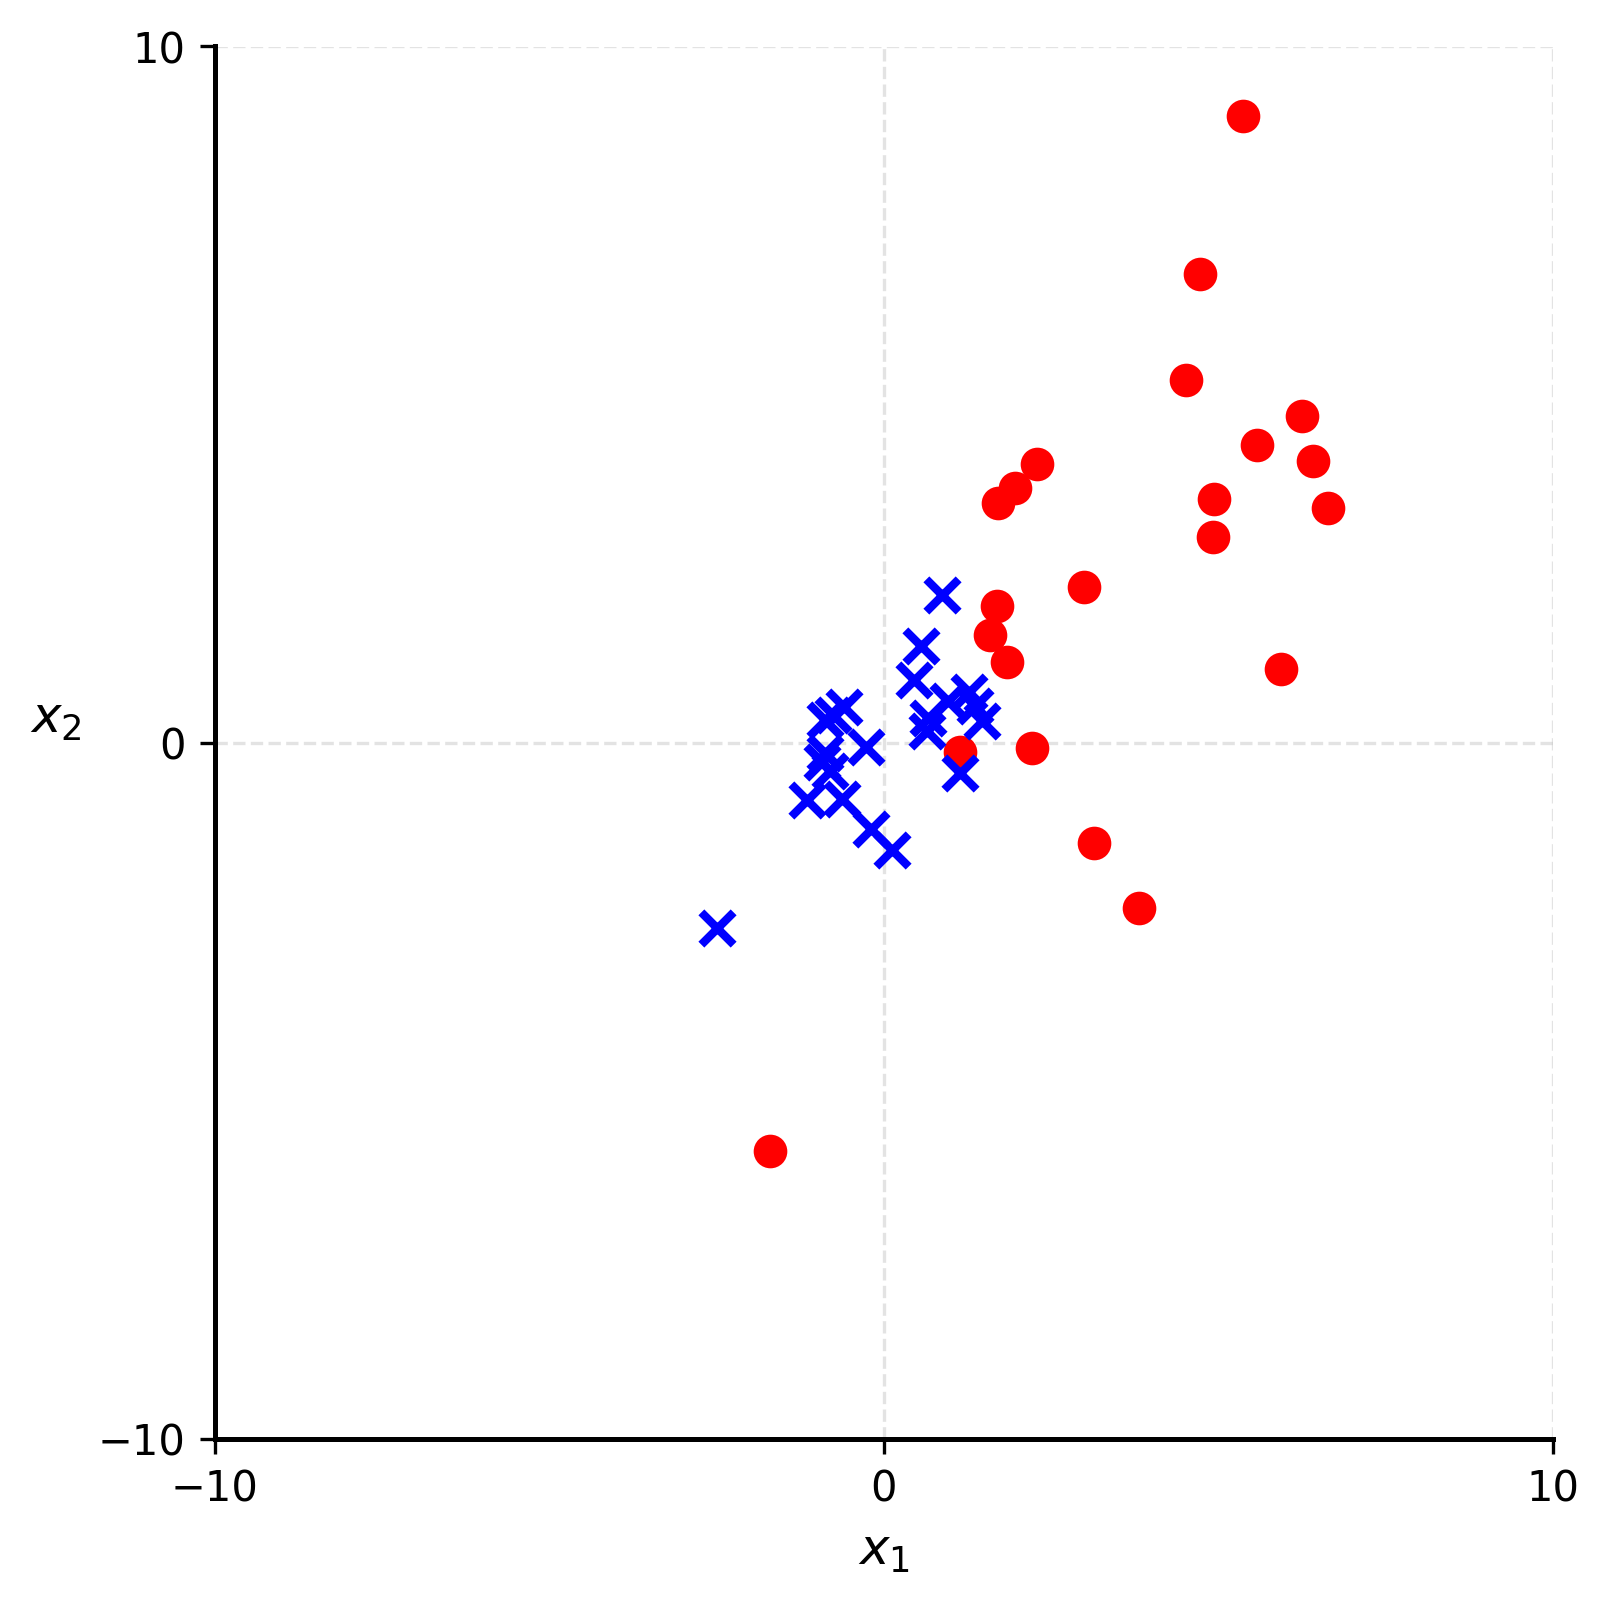

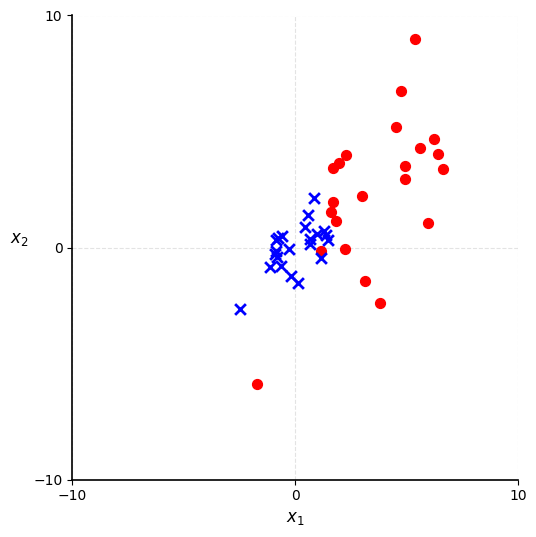

In [2]:
# Figure 7.7 の再現: 入力データ正規化の効果
fig_7_7_path, _ = generate_figure_7_7()
print(f"Figure 7.7 saved to: {fig_7_7_path}")

from IPython.display import Image, display
display(Image(filename=fig_7_7_path))


---

## 7.4.2 バッチ正規化 (Batch Normalization)

入力データの正規化と同様の数理的動機を、深層ネットワークの各隠れ層における中間変数（活性化）にも適用します。

### 勾配消失・爆発問題とヤコビ行列の積 (Eq 7.51)
多層ネットワークの第1層のパラメータに対する誤差関数の勾配は、微積分の連鎖律（Chain Rule）より各層のヤコビ行列の積として表されます：
$$
\frac{\partial E}{\partial w_i^{(1)}} = \sum_j \dots \sum_m \frac{\partial E}{\partial z_m^{(K)}} \frac{\partial z_m^{(K)}}{\partial z_l^{(K-1)}} \dots \frac{\partial z_j^{(1)}}{\partial w_i^{(1)}} \tag{7.51}
$$
層数 $K$ が大きくなると、ヤコビ行列の要素の大部分の絶対値が $1$ 未満であれば積は $0$ に急速に減衰し（**勾配消失, Vanishing Gradients**）、$1$ より大きければ $\infty$ に発散します（**勾配爆発, Exploding Gradients**）。

### バッチ正規化の定義 (Ioffe and Szegedy, 2015)
サイズ $K$ のミニバッチにおける隠れユニット $i$ の pre-activation $a_{ni}$ に対し、ミニバッチ統計量を計算します：
$$
\mu_i = \frac{1}{K} \sum_{n=1}^K a_{ni} \tag{7.52}
$$
$$
\sigma_i^2 = \frac{1}{K} \sum_{n=1}^K (a_{ni} - \mu_i)^2 \tag{7.53}
$$
$$
\widehat{a}_{ni} = \frac{a_{ni} - \mu_i}{\sqrt{\sigma_i^2 + \delta}} \tag{7.54}
$$
ここで $\delta > 0$（通常 $10^{-5}$）は数値安定化のための微小定数です。

### 学習可能パラメータ $\gamma_i$ と $\beta_i$ (Eq 7.55)
pre-activation を平均 0、分散 1 に固定してしまうと、層の自由度が低下して表現能力が制限されてしまいます。そこで、学習可能なスケールパラメータ $\gamma_i$ とシフトパラメータ $\beta_i$ を導入します：
$$
\widetilde{a}_{ni} = \gamma_i \widehat{a}_{ni} + \beta_i \tag{7.55}
$$
$\gamma_i, \beta_i$ は通常の重みやバイアスと共に勾配降下法によってエンドツーエンドで学習されます。

### 推論時（テスト時）の移動平均統計量 (Eq 7.56, 7.57)
テスト時にはミニバッチが存在せず、単一の入力サンプルに対して予測を行う必要があるため、訓練中に累積された指数移動平均（EMA）統計量を用います：
$$
\mu_i^{(\tau)} = \alpha \mu_i^{(\tau-1)} + (1 - \alpha) \mu_i \tag{7.56}
$$
$$
\sigma_i^{(\tau)} = \alpha \sigma_i^{(\tau-1)} + (1 - \alpha) \sigma_i \tag{7.57}
$$
ここで $\alpha$ は平滑化係数（例えば $0.9$）です。


---

## 7.4.3 層正規化 (Layer Normalization)

バッチ正規化には以下の実用上の制約が存在します：
- ミニバッチサイズ $K$ が小さい場合、標本平均・分散の推定ノイズが大きくなり不安定化する。
- 系列長が可変である再帰型ニューラルネットワーク（RNN）やTransformerでは、ステップごとに異なる分布となるためバッチ方向の統計量集約が適さない。
- 大規模分散訓練において、GPU間でミニバッチ統計量を同期する通信オーバーヘッドが大きい。

これらを解決するのが **層正規化 (Layer Normalization, Ba et al., 2016)** です。
層正規化では、各データポイント $n$ ごとに、その層の全隠れユニット $i = 1, \dots, M$ を横断して平均と分散を計算します：
$$
\mu_n = \frac{1}{M} \sum_{i=1}^M a_{ni} \tag{7.58}
$$
$$
\sigma_n^2 = \frac{1}{M} \sum_{i=1}^M (a_{ni} - \mu_n)^2 \tag{7.59}
$$
$$
\widehat{a}_{ni} = \frac{a_{ni} - \mu_n}{\sqrt{\sigma_n^2 + \delta}} \tag{7.60}
$$
そしてバッチ正規化と同様にアフィン変換 $\widetilde{a}_{ni} = \gamma_i \widehat{a}_{ni} + \beta_i$ を適用します。

### 層正規化の特徴
- 単一の入力サンプル完結で計算されるため、**訓練時と推論時で全く同一の処理** が行われ、移動平均統計量の保存やモード切り替えが不要。
- バッチサイズに一切依存しないため、バッチサイズ 1 のオンライン学習や超大規模モデルでも安定して動作します。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/7/result/fig_7_8_batch_vs_layer_norm.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_7_8_batch_vs_layer_norm.png
Figure 7.8 saved to: /home/student/Documents/GitHub/my_DeepLearning/7/result/fig_7_8_batch_vs_layer_norm.png


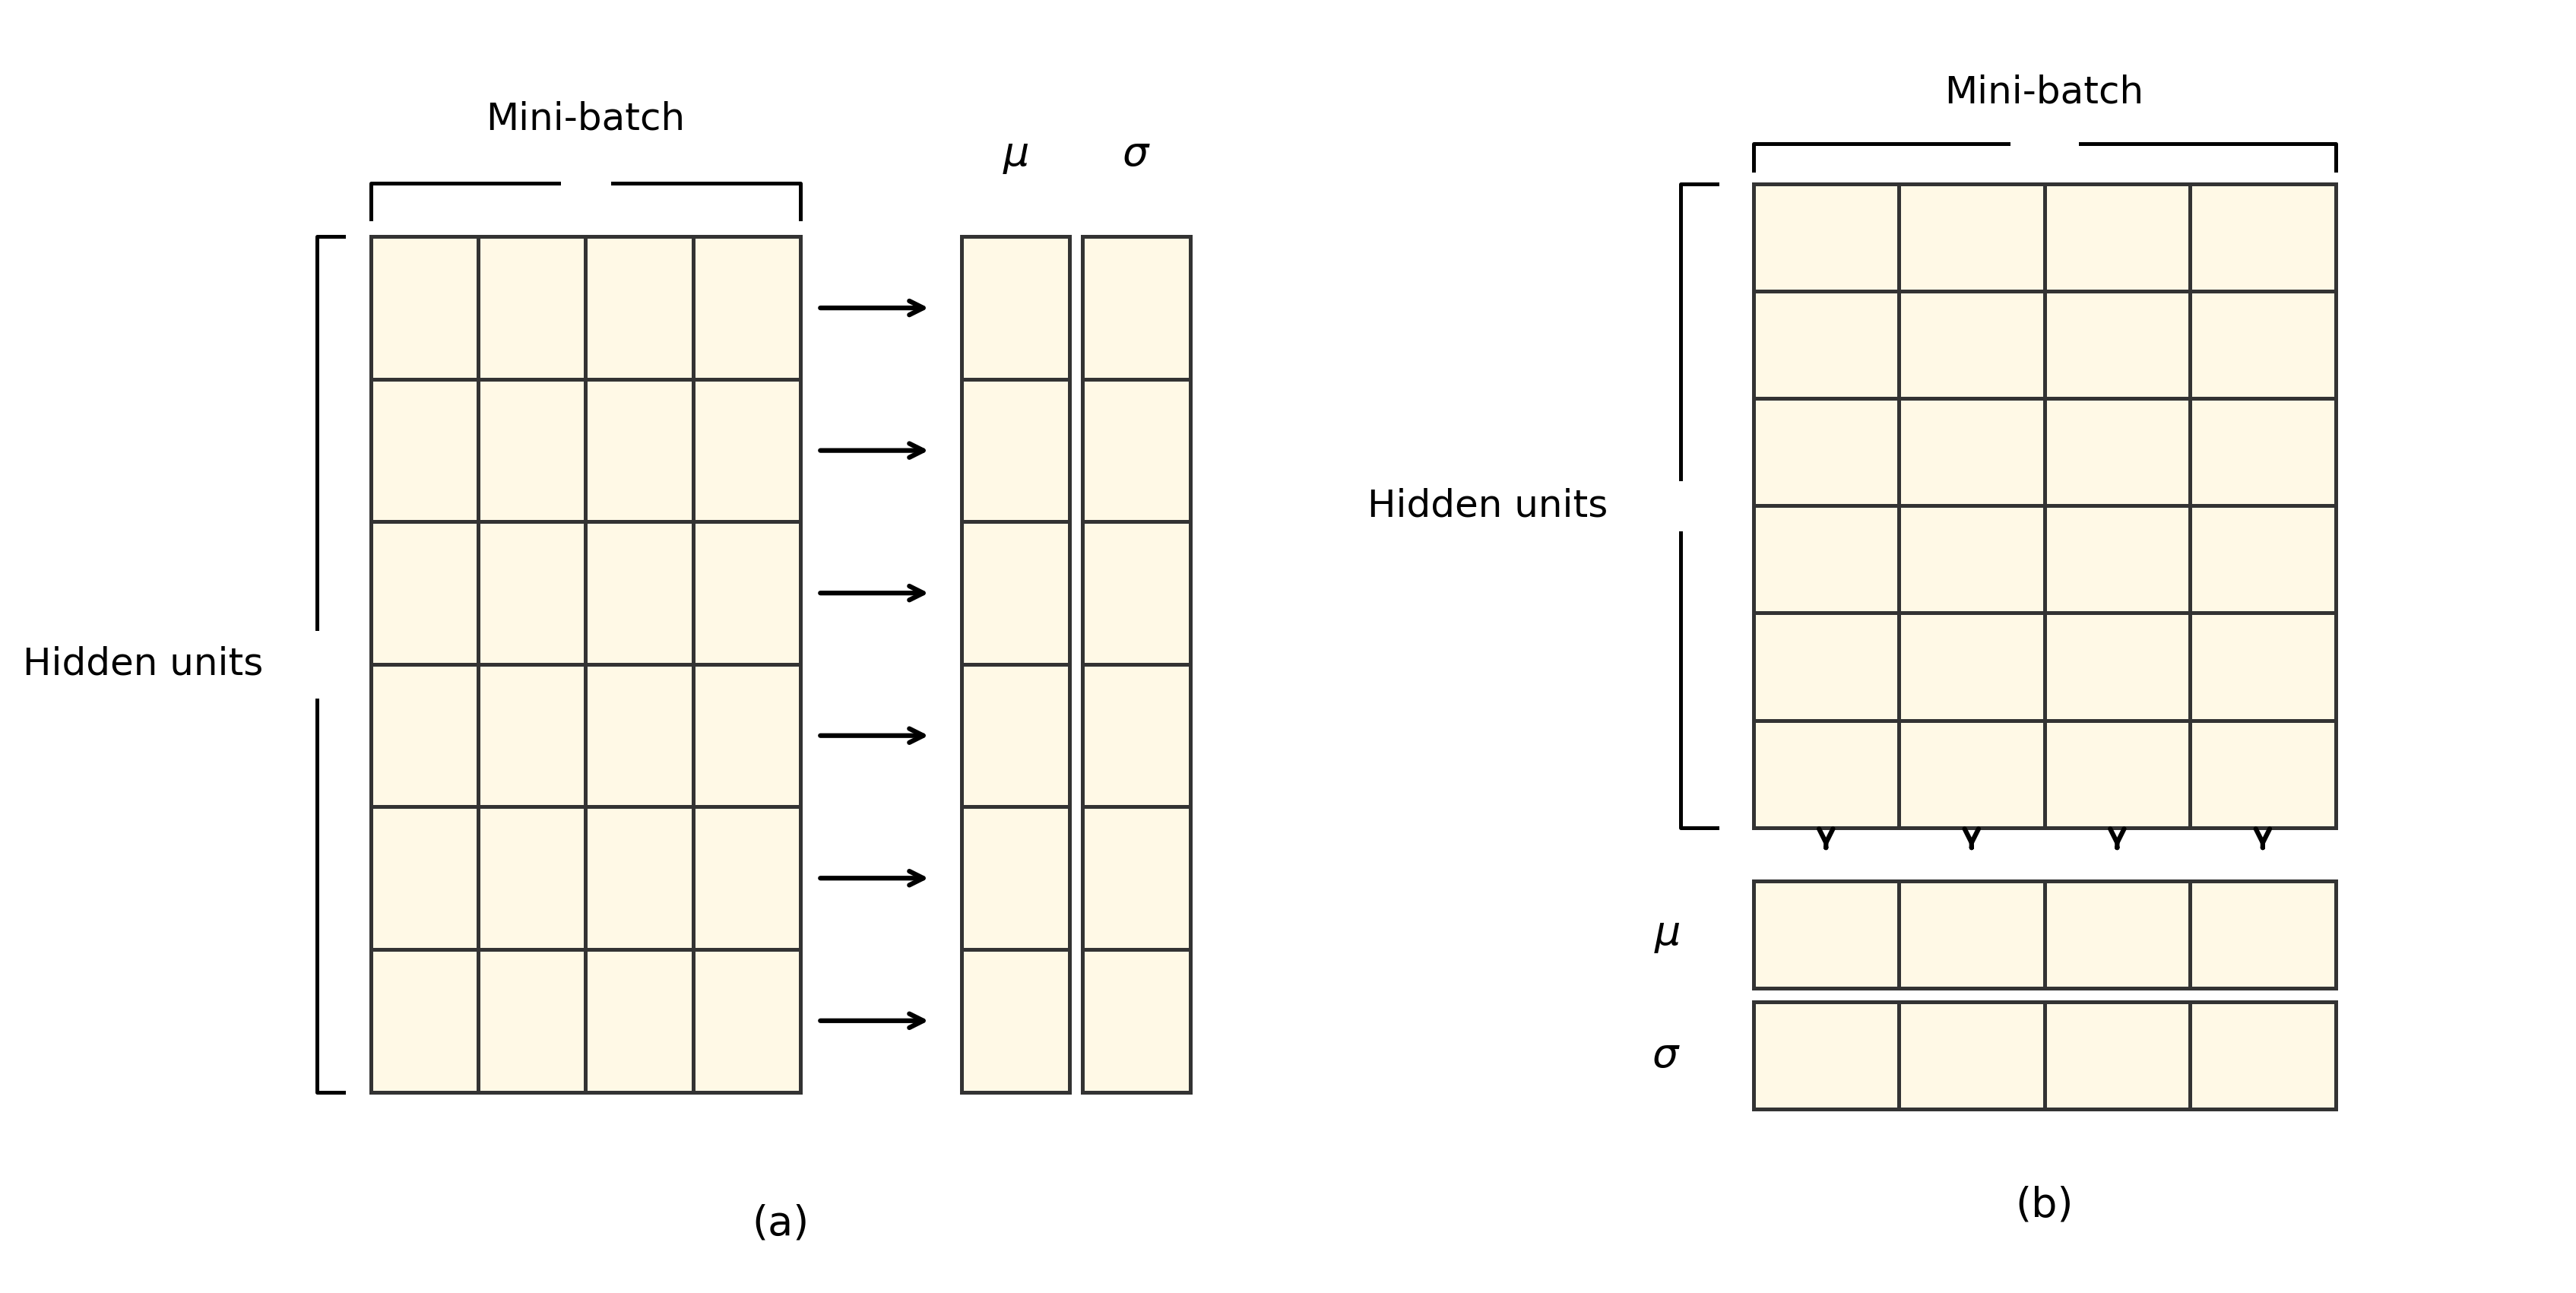

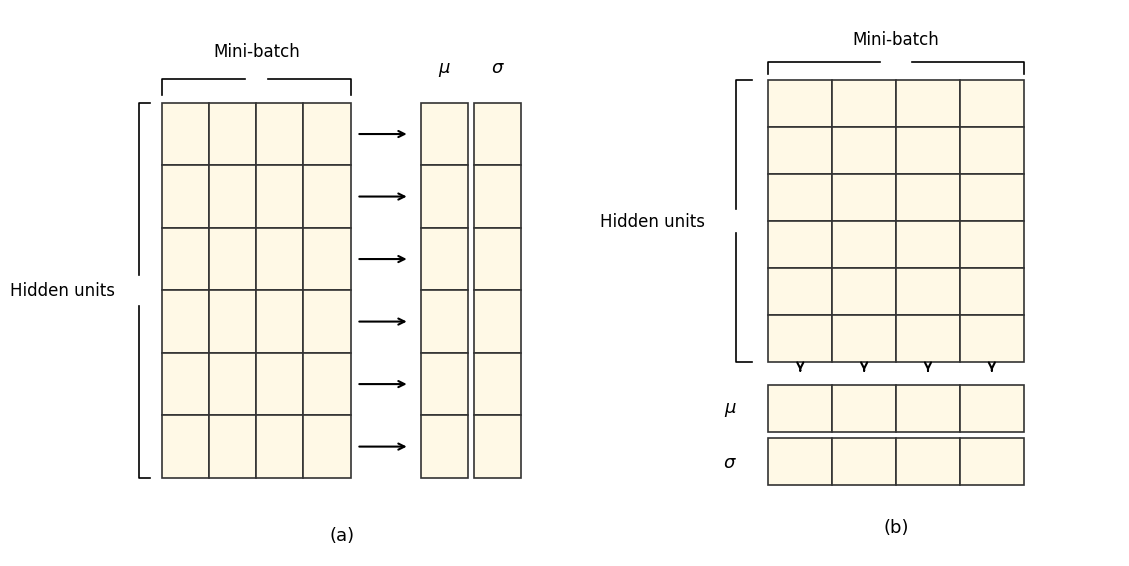

In [3]:
# Figure 7.8 の再現: バッチ正規化 (a) と層正規化 (b) の比較図
fig_7_8_path, _ = generate_figure_7_8()
print(f"Figure 7.8 saved to: {fig_7_8_path}")

from IPython.display import Image, display
display(Image(filename=fig_7_8_path))


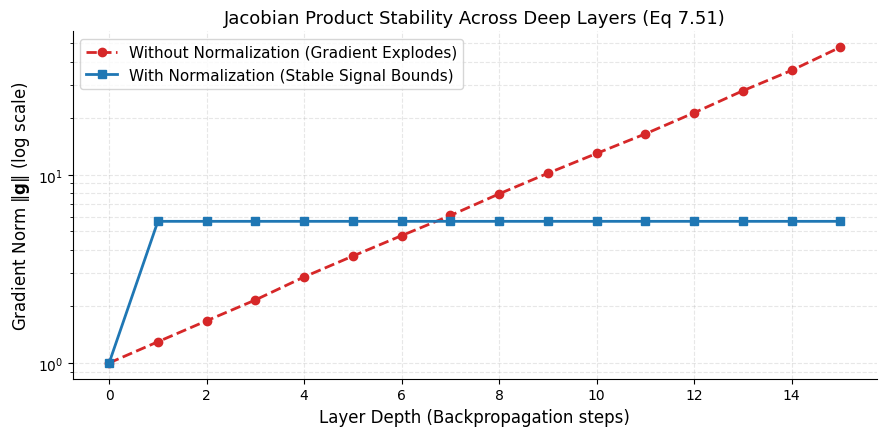

In [4]:
# 7.4.2項: ヤコビ行列の積 (Eq 7.51) における勾配爆発・消失シミュレーション
depth = 15
width = 32

# 重み行列のスケールがやや大きい場合 (weight_scale = 1.3)
norms_unnorm = simulate_jacobian_norm_propagation(
    depth=depth, width=width, weight_scale=1.3, normalize=False, num_trials=50, seed=42
)
norms_norm = simulate_jacobian_norm_propagation(
    depth=depth, width=width, weight_scale=1.3, normalize=True, num_trials=50, seed=42
)

plt.figure(figsize=(9, 4.5))
layers = np.arange(depth + 1)
plt.semilogy(layers, norms_unnorm, "o--", color="#d62728", lw=2, label="Without Normalization (Gradient Explodes)")
plt.semilogy(layers, norms_norm, "s-", color="#1f77b4", lw=2, label="With Normalization (Stable Signal Bounds)")
plt.xlabel("Layer Depth (Backpropagation steps)", fontsize=12)
plt.ylabel(r"Gradient Norm $\|\mathbf{g}\|$ (log scale)", fontsize=12)
plt.title(r"Jacobian Product Stability Across Deep Layers (Eq 7.51)", fontsize=13)
plt.grid(True, which="both", alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


In [5]:
# BatchNorm と LayerNorm の順伝播・逆伝播の動作確認
K_batch = 16
M_units = 8
rng = np.random.default_rng(42)

raw_inputs = rng.normal(loc=10.0, scale=5.0, size=(K_batch, M_units))

# 1. Batch Normalization
bn_layer = BatchNormalization(num_features=M_units)
out_bn = bn_layer.forward(raw_inputs, training=True)
print("=== Batch Normalization ===")
print("出力のバッチ方向平均 (各隠れユニット):", np.round(np.mean(out_bn, axis=0), 4))
print("出力のバッチ方向分散 (各隠れユニット):", np.round(np.var(out_bn, axis=0), 4))

# 2. Layer Normalization
ln_layer = LayerNormalization(num_features=M_units)
out_ln = ln_layer.forward(raw_inputs)
print("\n=== Layer Normalization ===")
print("出力の層方向平均 (各サンプル):", np.round(np.mean(out_ln, axis=1), 4))
print("出力の層方向分散 (各サンプル):", np.round(np.var(out_ln, axis=1), 4))


=== Batch Normalization ===
出力のバッチ方向平均 (各隠れユニット): [-0. -0. -0. -0. -0. -0. -0. -0.]
出力のバッチ方向分散 (各隠れユニット): [1. 1. 1. 1. 1. 1. 1. 1.]

=== Layer Normalization ===
出力の層方向平均 (各サンプル): [ 0.  0.  0. -0.  0.  0. -0. -0.  0.  0.  0. -0. -0.  0. -0.  0.]
出力の層方向分散 (各サンプル): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


---

## 7.4節のまとめと第7章の総括

本節（7.4節）では、ニューラルネットワークの各表現層における正規化技術を体系的に学びました：
1. **データ正規化 (7.4.1項)**: 入力特徴量をゼロ平均・単位分散に整え、ヘッセ行列の条件数を改善（**Figure 7.7**）。評価データには必ず訓練データの平均・分散を使用する。
2. **バッチ正規化 (7.4.2項)**: ミニバッチ内の各隠れユニットごとに正規化を行い、深層における勾配の消失・爆発を解消（**Figure 7.8 (a)**）。学習可能パラメータ $\gamma, \beta$ により表現能力を保持しつつ、推論時には移動平均統計量を用いる。
3. **層正規化 (7.4.3項)**: 各サンプル内の全隠れユニットにわたって正規化を行い、バッチサイズへの依存を解消（**Figure 7.8 (b)**）。TransformerやRNNなどの現代的アーキテクチャの標準手法。

---

### 第7章「勾配降下法」の総括
第7章を通じて、深層学習における最適化の全体系を修得しました：
- **7.1節 誤差曲面**: 局所2次展開、定常点分類、ヘッセ行列の固有値と等高線（Figure 7.1, 7.2）。
- **7.2節 勾配降下法による最適化**: 勾配情報の優位性 $\mathcal{O}(W^2)$ vs $\mathcal{O}(W^3)$、バッチGD、SGD（アルゴリズム 7.1）、ミニバッチ法（アルゴリズム 7.2）、He初期化 (Eq 7.23)。
- **7.3節 収束性**: 固有空間における収束条件、細長い谷における横断振動（Figure 7.3）、モーメンタム法（Figure 7.4–7.6, アルゴリズム 7.3）、学習率スケジュール、Adam最適化（アルゴリズム 7.4）。
- **7.4節 正規化**: 入力データ標準化（Figure 7.7）、バッチ正規化、層正規化（Figure 7.8）。

次章（第8章 誤差逆伝播法）では、これらすべての最適化アルゴリズムを駆動する計算エンジンである**誤差逆伝播法（Error Backpropagation）**の完全な数理アルゴリズムを探求します。
